# **Modeling caustics using simple polynomial models of Whitney's singularities**

Mikołaj Korzyński

The idea is to model lensing maps using the polynomial expression from the papers [Gaudi, Petters 2002a], [Gaudi, Petter 2002b] and [Congdon, Keeton, Nordgren 2008].

## **0. Imports, classes, definitions**

In [67]:
import numpy as np
import scipy as sp
import matplotlib as mpl
from matplotlib import pyplot as plt
import astropy
from astropy import units as u
from typing import Callable, Any

In [99]:
def clamp(a, lo, hi):
    return min(max(lo, a), hi)

## **1. Cusp**

$$u_1 = c\,\theta_1 + \frac{b}{2}\,\theta_2^2$$
$$u_2 = b\,\theta_1\,\theta_2 + a\,\theta_2^3$$

Here the dimension is:
* $[u_1] = [u_2] = [\theta_1] = [\theta_2] = {\rm rad}$
* $[c] = 1$
* $[b] = {\rm rad}^{-1}$
* $[a] = {\rm rad}^{-2}$.

#### **We introduce dimensionless variables**

$a =: \theta_*^{-2}$, where $\theta_*$ measures the angular size of the cusp ($[\theta_*] = {\rm rad}$).

Introduce dimensionless variables:
$$V_A:=\frac{\theta_A}{\theta_*}$$
$$U_A:=\frac{\theta_A}{\theta_*}$$
$$B:=b\,\theta_*$$
$$C:=c$$

The lensing equation takes the form of:

$$U_1 = C\,V_1 + \frac{B}{2}\,{V_2}^2$$
$$U_2 = B\,V_1\,V_2 + {V_2}^3$$

Assume we have a line in the source plane:
$$ \cos\varphi\,U_1 + \sin\varphi\,U_2 = \gamma$$

Substituting the lensing equation, we get on the lens plane the following:
$$\gamma = \sin\varphi\,{V_2}^3 + \cos\varphi\,\frac{B}{2}\,{V_2}^2 + B\,\sin\varphi\,V_1\,V_2 + C\,\cos\varphi\,V_1$$

**Idea:** make a contour plot of the function

$$\gamma_{\varphi,B,C}(V_1, V_2) = \sin\varphi\,{V_2}^3 + \cos\varphi\,\frac{B}{2}\,{V_2}^2 + B\,\sin\varphi\,V_1\,V_2 + C\,\cos\varphi\,V_1$$
in order to see what happens to the gradient of intensity near the cusp

### **1.1 Define the CuspLens class**

In [68]:
class CuspLens:
    def __init__(self, b: float, c: float, a: float = 1., name: str = "Cusp Lens") -> None:
        self.a = a
        self.b = b
        self.c = c
        self.name = name
        return
    
    
    def lensing_map(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        u1 = self.c * theta1 + self.b / 2 * theta2**2
        u2 = self.b * theta1 * theta2 + self.a * theta2**3
        return u1, u2
    
    
    def A(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        return np.array(
            (self.c,            self.b * theta2),
            (self.b * theta2,   3 * self.a * theta2**2 + self.b * theta1))
    
    
    def detA(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        return np.linalg.det(self.A(theta1, theta2))
    
    
    def detA2(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        return self.c * (3 * self.a * theta2**2 + self.b * theta1) - (self.b * theta2)**2
    
    
    def gamma(self, phi: float, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        return self.a * np.sin(phi) * theta2**3 + self.b / 2 * np.cos(phi) * theta2**2 + self.b * np.sin(phi) * theta1 * theta2   + np.cos(phi) * self.c * theta1
    

    def gamma2(self, phi: float, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        u1, u2 = self.lensing_map(theta1, theta2)
        gamma = np.cos(phi) * u1 + np.sin(phi) * u2
        return gamma    


    


### **1.2 Set up a lens and make a contour plot**

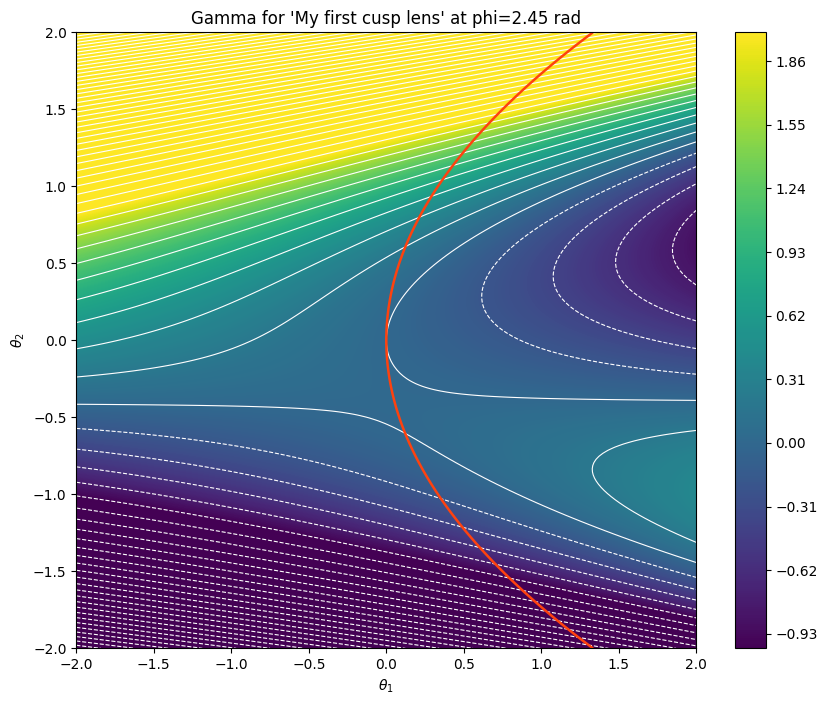

In [116]:
cl = CuspLens(a=1., b=-0.9, c=0.3, name="My first cusp lens")



V1_range = (-2., 2.)
N_V1 = 200
V2_range = (-2., 2.)
N_V2 = 200

phi =  np.pi * 0.78

V1, V2 = np.meshgrid(np.linspace(*V1_range, N_V1), np.linspace(*V2_range, N_V2))

gamma = cl.gamma2(phi=phi, theta1=V1, theta2=V2)

clamped_gamma = np.empty_like(gamma)

for i in range(gamma.shape[0]):
    for j in range(gamma.shape[1]):
        clamped_gamma[i, j] = clamp(gamma[i, j], -1., 2.)

fig, ax = plt.subplots(figsize=(10, 8))
plt.contourf(V1, V2, clamped_gamma, levels=300, cmap=mpl.colormaps.get_cmap('viridis'))
plt.colorbar()
plt.contour(V1, V2, gamma, levels=80, colors='white', linewidths=(0.8,))
plt.contour(V1, V2, cl.detA2(V1, V2), levels=np.array([0.]), colors='xkcd:orangered', linewidths=(1.8,))
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_title(f"Gamma for '{cl.name}' at phi={phi:.2f} rad")
plt.show()  

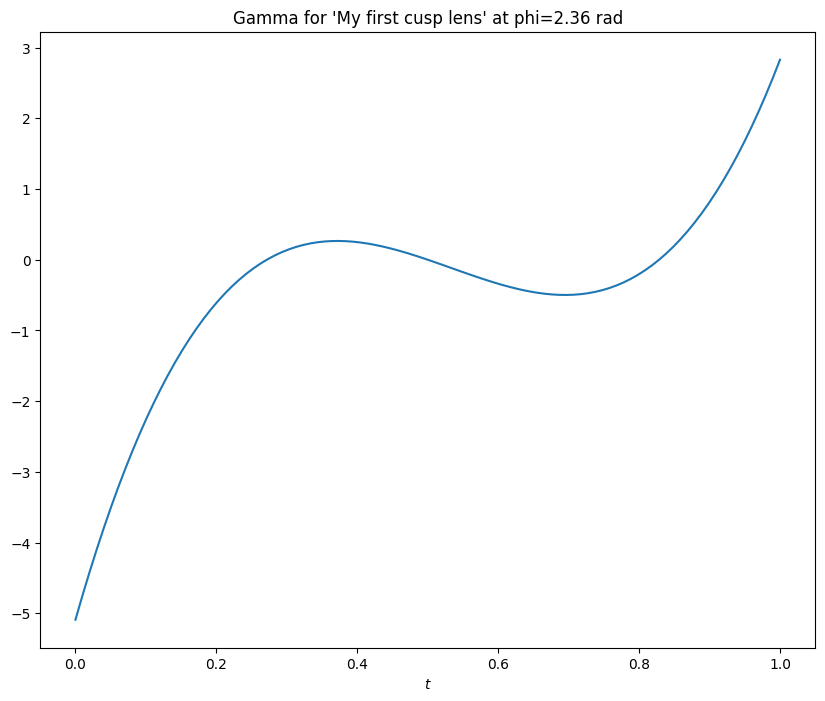

In [70]:
t = np.linspace(0, 1, 100)
theta1 = t * (V1_range[1] - V1_range[0]) + V1_range[0]
theta2 = t * (V2_range[1] - V2_range[0]) + V2_range[0]

fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(t, cl.gamma2(phi=phi, theta1=theta1, theta2=theta2))
ax.set_xlabel(r"$t$")
ax.set_title(f"Gamma for '{cl.name}' at phi={phi:.2f} rad")
plt.show()  

Plotting the determinan $\det A$ and the critical curve $\det A =0$

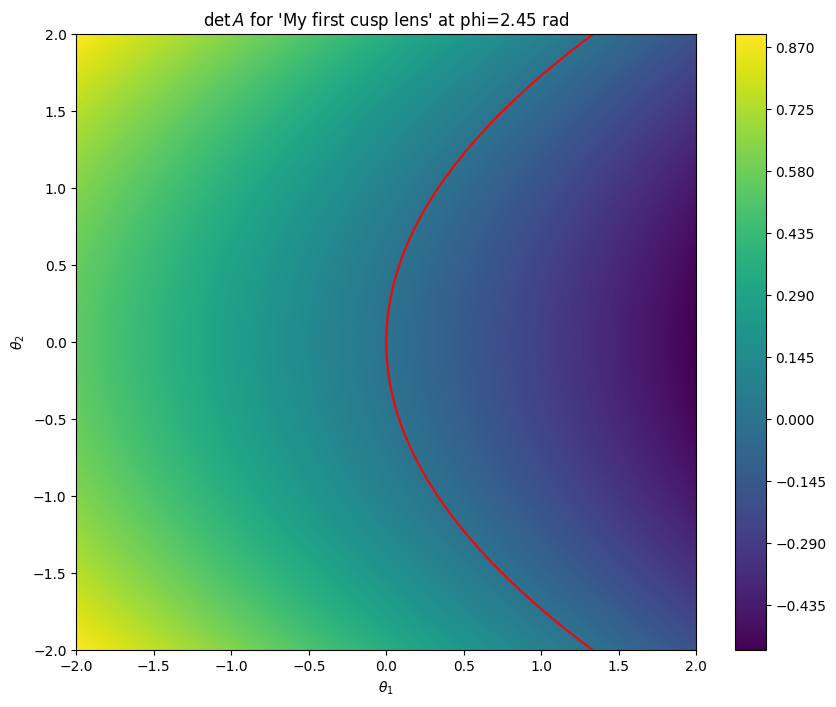

In [85]:
V1_range = (-2., 2.)
N_V1 = 200
V2_range = (-2., 2.)
N_V2 = 200

phi =  np.pi * 0.78

V1, V2 = np.meshgrid(np.linspace(*V1_range, N_V1), np.linspace(*V2_range, N_V2))

fig, ax = plt.subplots(figsize=(10, 8))
plt.contourf(V1, V2, cl.detA2(V1, V2), levels=300)
plt.colorbar()
plt.contour(V1, V2, cl.detA2(V1, V2), levels=[0.], colors=('red',))
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_title(r"$\det A$" + f" for '{cl.name}' at phi={phi:.2f} rad")
plt.show()  


---
## **Scratch notes**

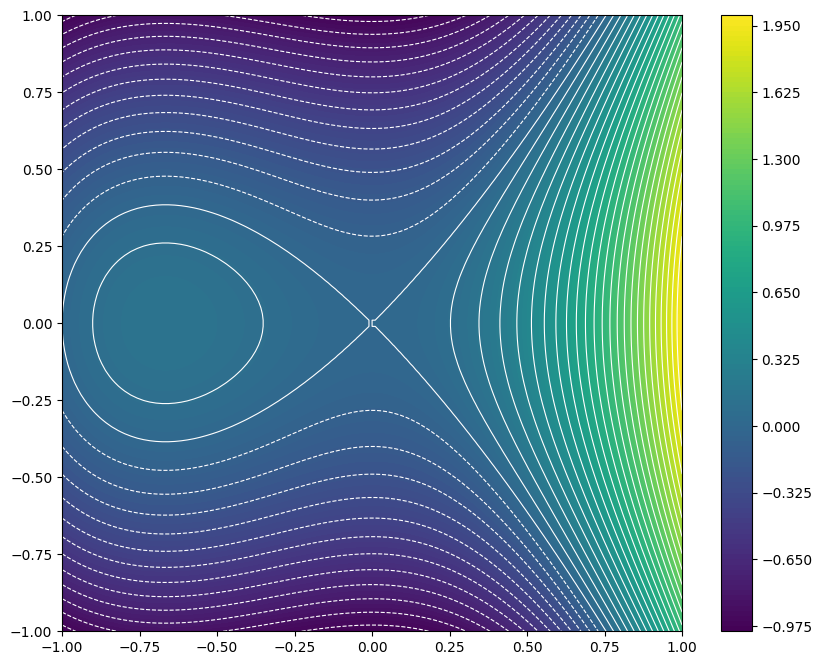

In [88]:
def f(x, y):
    return x**3 + x**2 - y**2


x_range = (-1., 1.)
N_x = 100
y_range = (-1., 1.)
N_y = 100


X, Y = np.meshgrid(np.linspace(*x_range, N_x), np.linspace(*y_range, N_y))


fig, ax = plt.subplots(figsize=(10, 8))
plt.contourf(X, Y, f(X, Y), levels=120)
plt.colorbar()
plt.contour(X, Y, f(X, Y), levels=40, colors='white', linewidths=(0.8, ))
plt.show()